In [ ]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
def load_case(vol_id):
    ct_path = f"/content/drive/MyDrive/LITS/volume-{vol_id}.nii"
    mask_path = f"/content/drive/MyDrive/LITS/segmentation-{vol_id}.nii"

    ct = nib.load(ct_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    mask_liver = (mask > 0).astype(np.float32)

    return ct, mask_liver


In [ ]:
def build_slice_dataset(ct, mask):
    images = []
    masks = []

    for i in range(ct.shape[2]):
        img = ct[:, :, i]
        msk = mask[:, :, i]

        # keep only slices with liver
        if np.sum(msk) == 0:
            continue

        images.append(img)
        masks.append(msk)

    return np.array(images), np.array(masks)



In [ ]:
all_X = []
all_Y = []

for vid in [0, 1, 2]:
    ct, mask_liver = load_case(vid)

    X_slices, Y_slices = build_slice_dataset(ct, mask_liver)

    all_X.append(X_slices)
    all_Y.append(Y_slices)

X = np.concatenate(all_X, axis=0)
Y = np.concatenate(all_Y, axis=0)

print("Total dataset shape:", X.shape)


Total dataset shape: (197, 512, 512)


In [ ]:
ct, mask_liver = load_case(2)
X_test, Y_test = build_slice_dataset(ct, mask_liver)

print("Test dataset shape:", X_test.shape)

Test dataset shape: (139, 512, 512)


In [ ]:
# clip to liver relevant HU range
X = np.clip(X, -200, 250)
X_test = np.clip(X_test, -200, 250)

# scale to 0–1 range
X = (X + 200) / 450.0
X_test = (X_test + 200) / 450.0

print("train min/max after norm:", X.min(), X.max())
print("test min/max after norm:", X_test.min(), X_test.max())

train min/max after norm: 0.0 1.0
test min/max after norm: 0.0 1.0


In [ ]:
X = np.expand_dims(X, axis=1)
Y = np.expand_dims(Y, axis=1)

X_test = np.expand_dims(X_test, axis=1)
Y_test = np.expand_dims(Y_test, axis=1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)
#Since, PyTorch expects (batch, channels, height, width)

X shape: (197, 1, 512, 512)
Y shape: (197, 1, 512, 512)
X_test shape: (139, 1, 512, 512)
Y_test shape: (139, 1, 512, 512)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class LiverDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataset = LiverDataset(X, Y)
test_dataset = LiverDataset(X_test, Y_test)

print("Dataset length:", len(dataset))
print("Dataset length:", len(test_dataset))


Dataset length: 197
Dataset length: 139


In [ ]:
loader = DataLoader(dataset, batch_size=4, shuffle=True)

for img, msk in loader:
    print("Batch image shape:", img.shape)
    print("Batch mask shape:", msk.shape)
    break


Batch image shape: torch.Size([4, 1, 512, 512])
Batch mask shape: torch.Size([4, 1, 512, 512])


UNET Definition

In [ ]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(64, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv2 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        b = self.bridge(p2)

        u1 = self.up1(b)
        u1 = torch.cat([u1, d2], dim=1)
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.conv2(u2)

        out = self.final(u2)
        return out


In [ ]:
#switching to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

print("Using device:", device)


Using device: cuda


In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
epochs = 20

model.train()

for epoch in range(epochs):
    total_loss = 0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")


Epoch 1, Loss: 0.2532
Epoch 2, Loss: 0.1110
Epoch 3, Loss: 0.0916
Epoch 4, Loss: 0.0734
Epoch 5, Loss: 0.0837
Epoch 6, Loss: 0.0747
Epoch 7, Loss: 0.0674
Epoch 8, Loss: 0.0602
Epoch 9, Loss: 0.0593
Epoch 10, Loss: 0.0533
Epoch 11, Loss: 0.0466
Epoch 12, Loss: 0.0424
Epoch 13, Loss: 0.0628
Epoch 14, Loss: 0.0585
Epoch 15, Loss: 0.0573
Epoch 16, Loss: 0.0448
Epoch 17, Loss: 0.0421
Epoch 18, Loss: 0.0417
Epoch 19, Loss: 0.0490
Epoch 20, Loss: 0.0357


In [ ]:
#dice function

def dice_score(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    target = target.float()

    intersection = (pred * target).sum()
    return (2. * intersection + eps) / (pred.sum() + target.sum() + eps)


In [ ]:
model.eval()
scores = []

with torch.no_grad():
    for img, mask in test_dataset:
        img = img.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0).to(device)

        out = model(img)
        out = torch.sigmoid(out)

        d = dice_score(out, mask)
        scores.append(d.item())

print("Average Dice:", sum(scores)/len(scores))


Average Dice: 0.8229452906736833


In [ ]:
model.eval()

pred_slices = []

with torch.no_grad():
    for img, _ in dataset:
        img = img.unsqueeze(0).to(device)
        out = model(img)
        out = torch.sigmoid(out)
        out = (out > 0.5).float()
        pred_slices.append(out.cpu().numpy()[0,0])

pred_slices = np.array(pred_slices)

print("Predicted volume shape:", pred_slices.shape)


Predicted volume shape: (197, 512, 512)


In [ ]:
# empty 3D volume

ct0, mask0 = load_case(0)
pred_volume = np.zeros_like(mask0)

idx = 0
for i in range(mask0.shape[2]):
    if np.sum(mask0[:,:,i]) == 0:
        continue

    pred_volume[:,:,i] = pred_slices[idx]
    idx += 1

print("Rebuilt volume shape:", pred_volume.shape)


Rebuilt volume shape: (512, 512, 75)


In [ ]:
np.save("/content/drive/MyDrive/LITS/pred_volume.npy", pred_volume)


In [ ]:
print(X_test.min(), X_test.max())


0.0 1.0


In [ ]:
img, mask = test_dataset[0]

img_t = img.unsqueeze(0).to(device)

with torch.no_grad():
    out = model(img_t)
    out = torch.sigmoid(out)

pred = out.cpu().numpy()[0,0]

print("Pred min/max:", pred.min(), pred.max())


Pred min/max: 6.1666876e-35 0.9131236


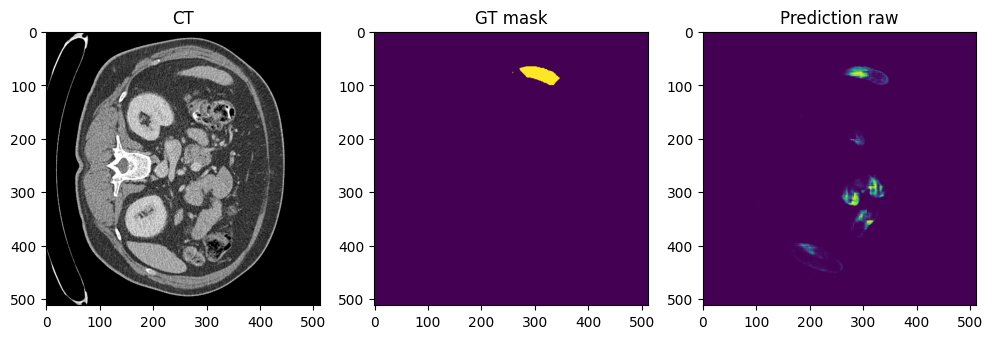

In [ ]:
import matplotlib.pyplot as plt

img, mask = test_dataset[10]

img_t = img.unsqueeze(0).to(device)

with torch.no_grad():
    out = model(img_t)
    out = torch.sigmoid(out)

pred = out.cpu().numpy()[0,0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("CT")
plt.imshow(img[0], cmap="gray")

plt.subplot(1,3,2)
plt.title("GT mask")
plt.imshow(mask[0])

plt.subplot(1,3,3)
plt.title("Prediction raw")
plt.imshow(pred)

plt.show()
